In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# -------------------------
# Style
# -------------------------
sns.set_theme(style="white", context="paper")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.linewidth": 1.0,
})

# -------------------------
# Project paths
# -------------------------
# The Jupyter Notebook working directory should be:
# Code/Figures Python
project_dir = Path.cwd()

data_dir = project_dir / "Data"
results_dir = project_dir / "Results"

# -------------------------
# Inputs
# -------------------------
file = data_dir / "MSA_Perm_Connectome_Test.xlsx"

sheets = {
    "Perm_Connections_For_Plot": "Permute edges (connections)",
    "Perm_Nodes_For_Plot": "Permute nodes (relabeling)",
}

orig_ccc = 0.395649442591783  # original connectome CCC (solid line)

out_dir = results_dir / "MSA_Perm_Connectome_Test"
out_dir.mkdir(parents=True, exist_ok=True)

# Colors
HIST_COLOR = "#9BBCE5"   # light blue
ORIG_COLOR = "#2C3E50"   # dark solid line
P95_COLOR  = "#D55E00"   # orange/red for percentile line

# -------------------------
# Plot helper
# -------------------------
def plot_perm_hist(ccc_vals, title, save_prefix, bins=30):
    ccc_vals = np.asarray(ccc_vals, dtype=float)
    ccc_vals = ccc_vals[np.isfinite(ccc_vals)]

    p95 = np.percentile(ccc_vals, 95)

    fig, ax = plt.subplots(figsize=(5.0, 3.8))

    # Histogram
    ax.hist(
        ccc_vals,
        bins=25,
        density=False,
        color=HIST_COLOR,
        alpha=0.6,
        edgecolor="white",
        linewidth=0.8
    )

    ax.set_xlim(-0.05, 0.5)
    ymax = ax.get_ylim()[1]
    ax.set_ylim(0, ymax * 1.15)

    # Optional smooth curve (kept commented out)
    # sns.kdeplot(ccc_vals, ax=ax, linewidth=1.6, color=HIST_COLOR)

    line_orig = ax.axvline(
        orig_ccc,
        color=ORIG_COLOR,
        linewidth=2.0,
        linestyle="-"
    )

    line_p95 = ax.axvline(
        p95,
        color=P95_COLOR,
        linewidth=2.0,
        linestyle="--"
    )

    # Labels
    ax.set_title(title)
    ax.set_xlabel("Model performance (CCC)")
    ax.set_ylabel("Count")

    # Legend
    ax.legend(
        handles=[line_orig, line_p95],
        labels=[
            f"Original CCC = {orig_ccc:.3f}",
            f"95th percentile = {p95:.3f}"
        ],
        frameon=False,
        loc="upper right"
    )

    # Ticks outward + visible left/bottom spines only
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    ax.tick_params(
        axis="both",
        which="major",
        bottom=True,
        left=True,
        direction="out",
        length=4,
        width=1.0,
        colors="k"
    )
    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    plt.tight_layout()

    fig.savefig(out_dir / f"{save_prefix}.pdf", bbox_inches="tight")
    fig.savefig(out_dir / f"{save_prefix}.png", dpi=300, bbox_inches="tight")
    plt.show()

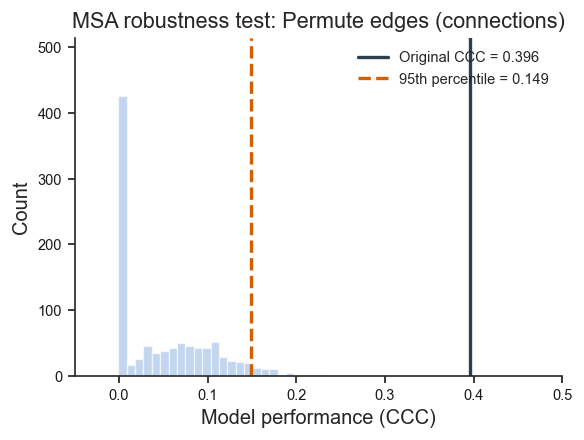

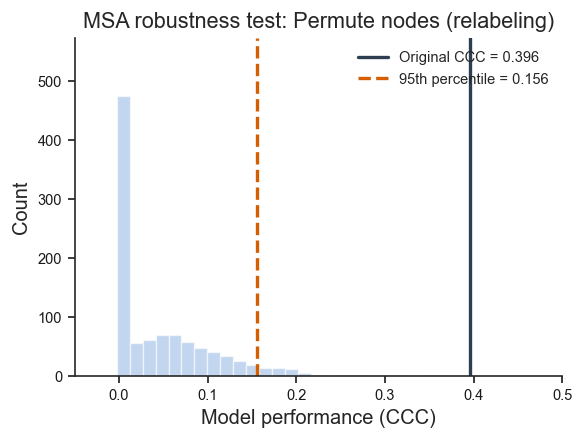

In [3]:
# -------------------------
# Run
# -------------------------
for sheet, nice_name in sheets.items():
    df = pd.read_excel(file, sheet_name=sheet, header=0)

    # Take 2nd column as CCC (NO., CCC)
    ccc = df.iloc[:, 1].dropna().to_numpy()

    plot_perm_hist(
        ccc_vals=ccc,
        title=f"MSA robustness test: {nice_name}",
        save_prefix=f"MSA_{sheet}_hist"
    )